In [1]:
import sys;sys.path.append('../..')
from abslithist import *

In [195]:
def load_scores():
    PATH_DATA_SCORES = os.path.join(PATH_DATA,'scores')
    fns = [os.path.join(PATH_DATA_SCORES,fn) for fn in os.listdir(PATH_DATA_SCORES) if fn.endswith('.v2.pkl')]# and not fn.endswith('.v2.pkl')]
    
    dfs = []
    for fn in fns:
        df = pd.read_pickle(fn).reset_index()
        df['corpus'] = fn.split('.')[2]
        df['decade'] = df['year'] // 10 * 10
        df['quartercentury'] = df['year'] // 25 * 25
        df['halfcentury'] = df['year'] // 50 * 50
        df = df.set_index(['genre','corpus','year'])
        dfs.append(df)
    df = pd.concat(dfs)
    return df.sort_index()
    

In [196]:
def get_avgs_df(df, gby=["genre", "corpus","decade"], y="Abs-Conc.Median.median", min_texts=100):
    df = df.copy()
    df = df.groupby(gby).filter(lambda x: x.num_texts.sum() >= min_texts)
    df[y] = (df[y] - df[y].mean()) / df[y].std()
    stats_df = (
        df.groupby(gby)[y]
        .agg(
            mean=np.mean,
            stderr=lambda x: x.std() / np.sqrt(len(x)),
            count=len,
        )
    )
    return stats_df.sort_index()#.sort_values('mean', ascending=False)


In [197]:
df = load_scores()
# df = df.query('num_texts>=2')
df

Abs-Conc.LSN-Hapt.C16  Abs-Conc.LSN-Imag.C16  \
genre     corpus         year                                                 
Biography HathiBio       1700              -1.313897              -1.965692   
                         1700              -1.329312              -1.984858   
                         1700              -1.332592              -1.962978   
                         1700              -1.275613              -1.902614   
                         1700              -1.313853              -1.955018   
...                                              ...                    ...   
Verse     ChadwyckPoetry 2004              14.861334              13.367864   
                         2004              14.709243              13.262935   
                         2004              14.895554              13.382258   
                         2004              14.812991              13.393358   
                         2004              14.731998              13.364158   

                               Abs-Conc.MRC-Conc.C16  Abs-Conc.MRC-Imag.C16  \
genre     corpus         year                                                 
Biography HathiBio       1700              -2.241034              -1.722778   
                         1700              -2.251821              -1.742685   
                         1700              -2.213159              -1.713719   
                         1700              -2.184876              -1.687676   
                         1700              -2.218106              -1.717414   
...                                              ...                    ...   
Verse     ChadwyckPoetry 2004              13.546540              17.305520   
                         2004              13.435480              17.170128   
                         2004              13.588211              17.330819   
                         2004              13.581557              17.286144   
                         2004              13.511301              17.224368   

                               Abs-Conc.MT-Conc.C16  Abs-Conc.Median.C16  \
genre     corpus         year                                              
Biography HathiBio       1700             -2.496807            -2.090003   
                         1700             -2.499726            -2.100724   
                         1700             -2.454231            -2.073422   
                         1700             -2.428436            -2.033596   
                         1700             -2.473164            -2.077707   
...                                             ...                  ...   
Verse     ChadwyckPoetry 2004              9.949271            13.207885   
                         2004              9.856807            13.095761   
                         2004             10.020200            13.265692   
                         2004              9.985109            13.213721   
                         2004              9.921339            13.155895   

                               Abs-Conc.PAV-Conc.C16  Abs-Conc.PAV-Imag.C16  \
genre     corpus         year                                                 
Biography HathiBio       1700              -2.193084              -1.928794   
                         1700              -2.198905              -1.942543   
                         1700              -2.164229              -1.913073   
                         1700              -2.133062              -1.891928   
                         1700              -2.163935              -1.915774   
...                                              ...                    ...   
Verse     ChadwyckPoetry 2004              13.584528              16.115666   
                         2004              13.466956              16.036904   
                         2004              13.628119              16.179625   
                         2004              13.629172              16.137873   
                         2004         

In [156]:
df = df.query('corpus!="HathiEngLit"')
df = df.query('corpus!="ECCO_TCP"')
df = df.query('corpus!="EEBO_TCP"')
# df.groupby(['genre','corpus']).size()

In [181]:
yearcol = 'decade'
odf = get_avgs_df(df, gby=["genre", "corpus", yearcol], y="Abs-Conc.Median.median", min_texts=25)
odf

mean    stderr  count
genre     corpus         decade                           
Biography HathiBio       1700   -0.614822  0.039935     90
                         1710   -0.349444  0.042817     90
                         1720   -0.132842  0.030254    100
                         1730   -0.347488  0.050323    100
                         1740   -0.309047  0.038611    100
...                                   ...       ...    ...
Verse     ChadwyckPoetry 1960    1.577477  0.027924    100
                         1970    1.387702  0.038805    100
                         1980    1.714959  0.041200    100
                         1990    2.716887  0.150020     90
                         2000    4.289960  0.451272     50

[297 rows x 3 columns]

In [182]:
def plot_avgs_df(figdf, **labs):
    fig = (
        p9.ggplot(
            figdf,
            p9.aes(x=yearcol, y='mean', color='genre'),
        )
        + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=10, alpha=0.75)
        + p9.geom_line()
        # + p9.geom_point(p9.aes(y='mean',size='count'), shape='x')
        + p9.facet_wrap('genre', scales='free_y')
        + p9.theme_minimal()
        + p9.scale_size_continuous(range=(.5, 5))
        # + p9.geom_smooth(method='loess', span=0.3, alpha=0.15, size=.5)
        + p9.labs(**labs)
        + p9.theme(figure_size=(12,6), dpi=300)
        # + p9.scale_y_continuous(limits=(-4,4))
        # + p9.scale_y_continuous(limits=(-2,2))
    )
    return fig


In [183]:
genres = {'Essay','Fiction', 'Verse', 'Treatise', 'Sermon', 'Periodical'}
# genres = {'Essay','Fiction', 'Verse'}
genres = {'Essay','Fiction', 'Verse'}
genres = {'Essay', 'Sermon','Fiction', 'Verse'}

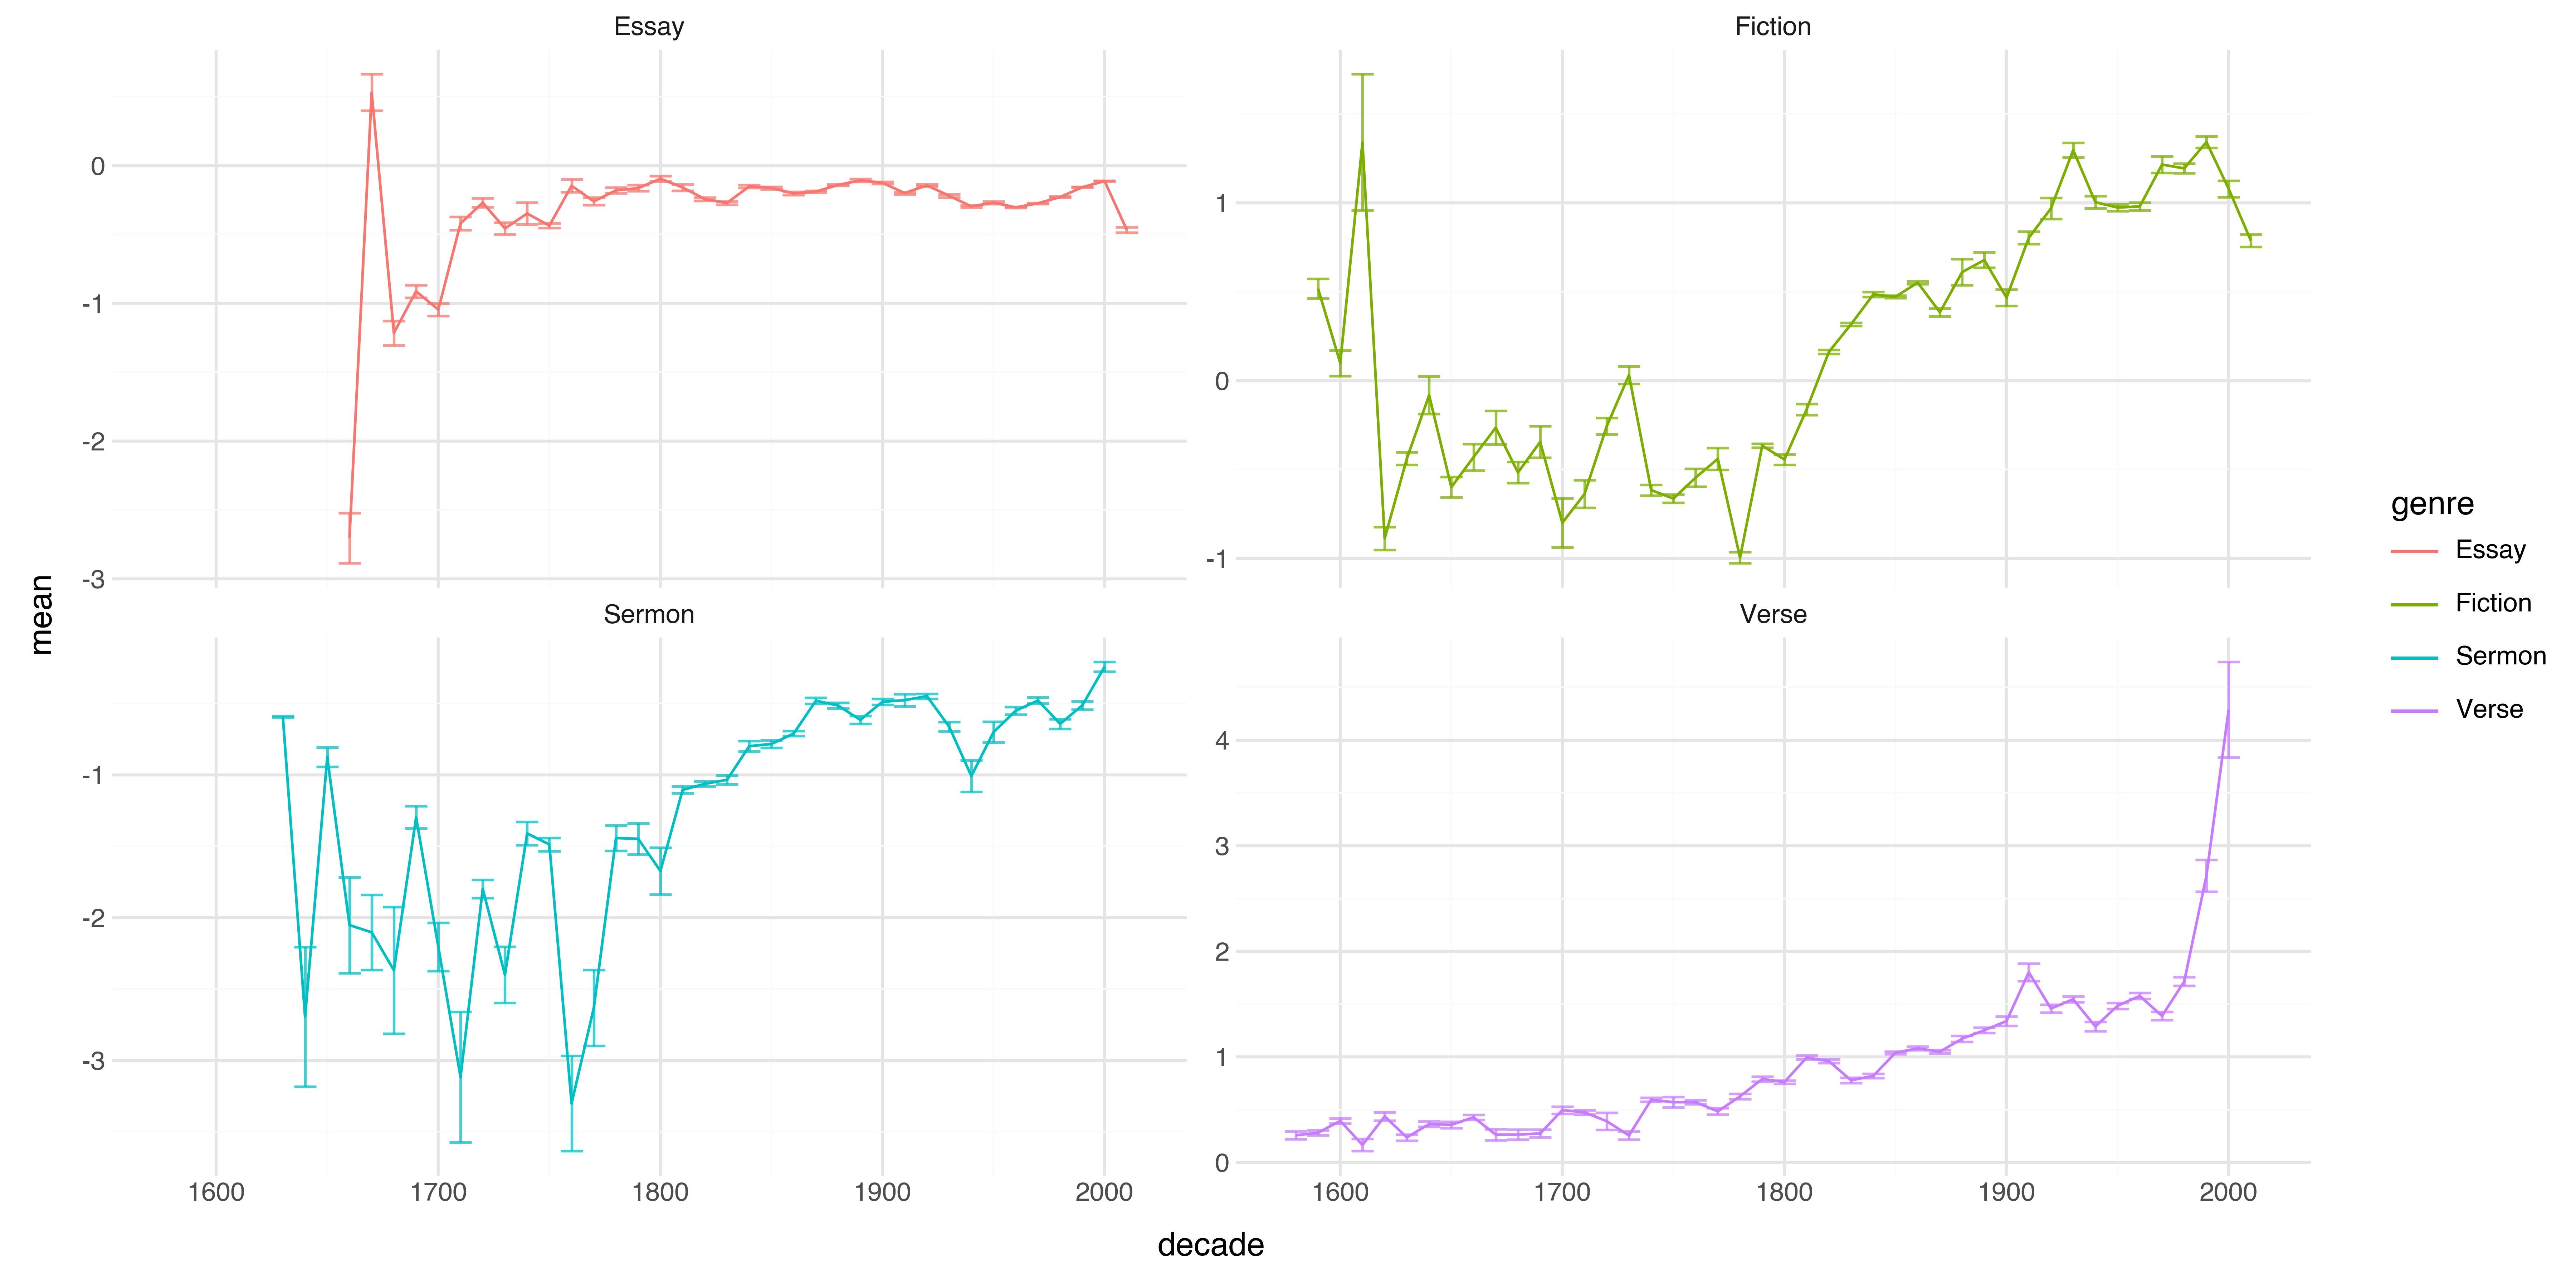

In [184]:
figdf = odf.reset_index()
figdf = figdf[figdf.genre.isin(genres)]

plot_avgs_df(figdf)